In [1]:
# ==========================================
# 1. IMPORT LIBRARY
# ==========================================
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import librosa
import librosa.display

from IPython.display import Audio

plt.rcParams["figure.figsize"] = (12,4)

In [2]:
# ==========================================
# 2. EXTRACT DATASET (UNZIP)
# ==========================================
with zipfile.ZipFile("archive.zip", "r") as zip_ref:
    zip_ref.extractall("dataset")

print("Dataset berhasil diekstrak!")

Dataset berhasil diekstrak!


In [3]:
# ==========================================
# 3. CEK ISI FOLDER ZIP 
# ==========================================
os.listdir("dataset")

['AudioWAV']

### PREPROCESSING

In [4]:
# ==========================================
# 4. LOAD DATASET
# ==========================================
folder_path = "dataset/AudioWAV"

audio_files = os.listdir(folder_path)

print("Jumlah file :", len(audio_files))
print(audio_files[:10])

Jumlah file : 7442
['1001_DFA_ANG_XX.wav', '1001_DFA_DIS_XX.wav', '1001_DFA_FEA_XX.wav', '1001_DFA_HAP_XX.wav', '1001_DFA_NEU_XX.wav', '1001_DFA_SAD_XX.wav', '1001_IEO_ANG_HI.wav', '1001_IEO_ANG_LO.wav', '1001_IEO_ANG_MD.wav', '1001_IEO_DIS_HI.wav']


In [5]:
# ==========================================
# 5. DATAFRAME : PARSING LABEL EMOSI
# ==========================================
data = []

for file in audio_files:

    emotion = file.split("_")[2]

    data.append({
        "filename": file,
        "emotion": emotion
    })

df = pd.DataFrame(data)

df.head()

,filename,emotion
0,1001_DFA_ANG_XX.wav,ANG
1,1001_DFA_DIS_XX.wav,DIS
2,1001_DFA_FEA_XX.wav,FEA
3,1001_DFA_HAP_XX.wav,HAP
4,1001_DFA_NEU_XX.wav,NEU


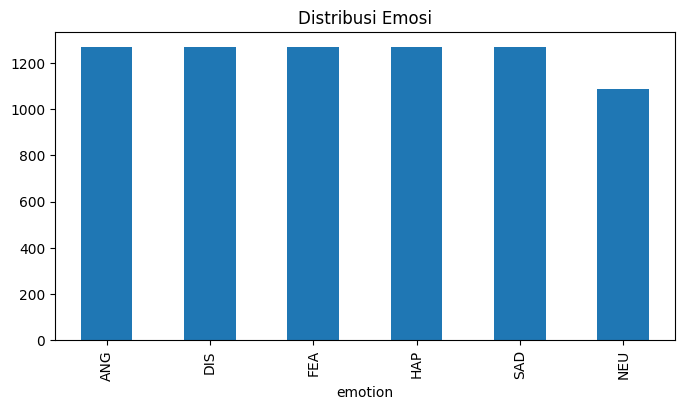

In [6]:
# ==========================================
# 6. EDA : DISTRIBUSI EMOSI 
# ==========================================
df["emotion"].value_counts()

df["emotion"].value_counts().plot(
    kind="bar",
    figsize=(8,4)
)

plt.title("Distribusi Emosi")
plt.show()

In [7]:
# ==========================================
# 7. FILTER 4 EMOSI
# ==========================================
selected = ["ANG","HAP","SAD","NEU"]

df = df[df["emotion"].isin(selected)]

df["emotion"].value_counts()

emotion
ANG    1271
HAP    1271
SAD    1271
NEU    1087
Name: count, dtype: int64

In [8]:
# ==========================================
# 8. SAMPLING DATASET : 20 DATA PER EMOSI (N=80 DATA)
# ==========================================
sample_df = (
    df.groupby("emotion")
      .sample(n=20, random_state=123)
)

sample_df = sample_df.reset_index(drop=True)

print(sample_df.shape)

sample_df.head()

(80, 2)


,filename,emotion
0,1004_IEO_ANG_HI.wav,ANG
1,1077_IEO_ANG_HI.wav,ANG
2,1017_IWL_ANG_XX.wav,ANG
3,1086_IOM_ANG_XX.wav,ANG
4,1021_ITH_ANG_XX.wav,ANG


In [9]:
# ==========================================
# 9. EDA : PLAY AUDIO
# ==========================================
sample_audio = sample_df.iloc[0]["filename"]

audio_path = os.path.join(
    folder_path,
    sample_audio
)

Audio(audio_path)

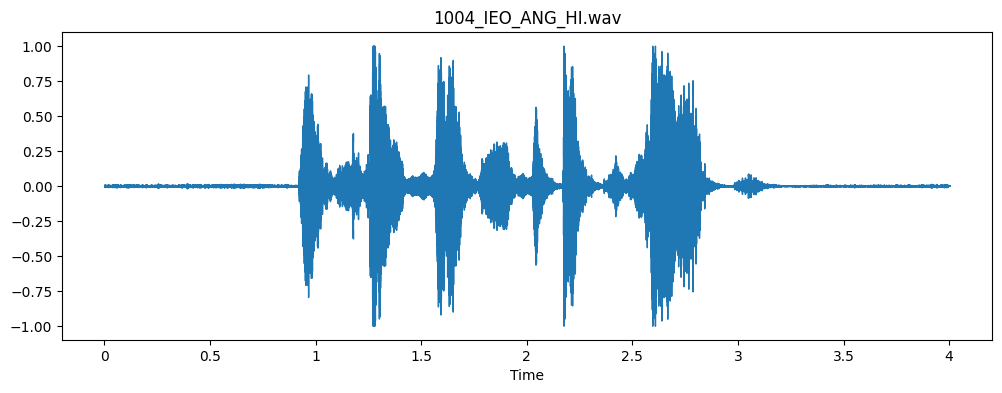

In [10]:
# ==========================================
# 10. VISUALISASI : WAVEFORM
# ==========================================
y, sr = librosa.load(
    audio_path,
    sr=None
) 
#y = sinyal audio
#sr = sampling rate

plt.figure(figsize=(12,4))

librosa.display.waveshow(
    y,
    sr=sr
)

plt.title(sample_audio)

plt.show()

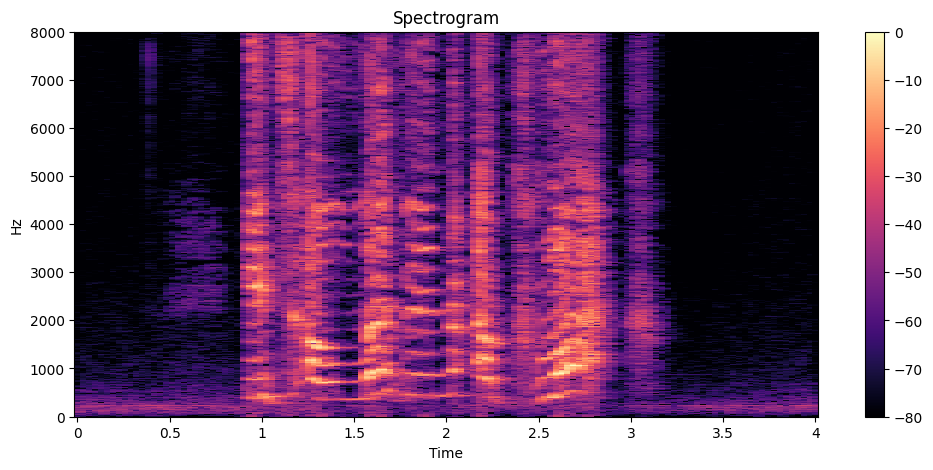

In [11]:
# ==========================================
# 11. VISUALISASI : SPECTROGRAM
# ==========================================
D = librosa.amplitude_to_db(
    np.abs(
        librosa.stft(y)
    ),
    ref=np.max
)

plt.figure(figsize=(12,5))

librosa.display.specshow(
    D,
    sr=sr,
    x_axis="time",
    y_axis="hz"
)

plt.colorbar()

plt.title("Spectrogram")

plt.show()

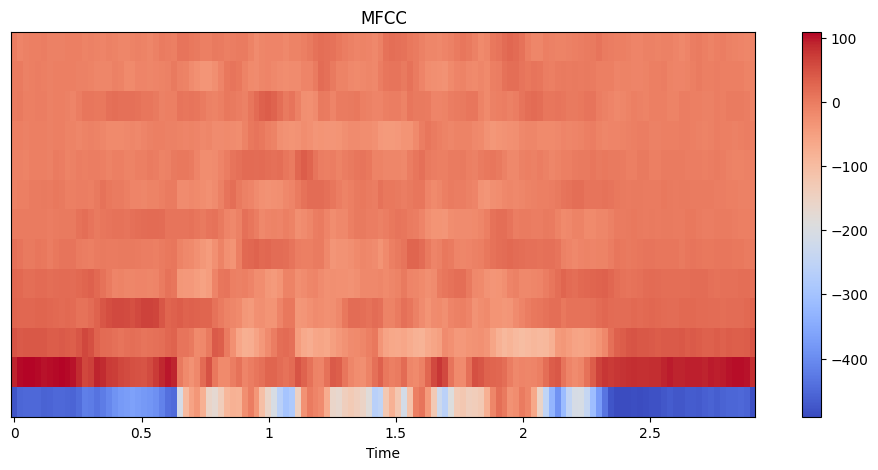

In [12]:
# ==========================================
# 12. PREPROCESSING UTAMA : MFCC EXTRACTION
# ==========================================
mfcc = librosa.feature.mfcc(
    y=y,
    sr=sr,
    n_mfcc=13
)

plt.figure(figsize=(12,5))

librosa.display.specshow(
    mfcc,
    x_axis="time"
)

plt.colorbar()

plt.title("MFCC")

plt.show()

In [13]:
# ==========================================
# (Opsional) Normalisasi MFCC
# ==========================================
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

mfcc_norm = scaler.fit_transform(
    mfcc.T
).T

### PEMODELAN DTW ANALISIS

In [14]:
# ==========================================
# 13. INSTALL DTW 
# ==========================================
#!pip install dtw-python

In [15]:
# ==========================================
# 14. IMPORT DTW 
# ==========================================
from dtw import dtw

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



In [16]:
# ==========================================
# 15. PILIH 2 AUDIO
# ==========================================
audio1 = sample_df.iloc[0]["filename"]
audio2 = sample_df.iloc[1]["filename"]

path1 = os.path.join(folder_path, audio1)
path2 = os.path.join(folder_path, audio2)

print(audio1)
print(audio2)

1004_IEO_ANG_HI.wav
1077_IEO_ANG_HI.wav


In [17]:
# ==========================================
# 16. EKSTRASI MFCC KEDUA AUDIO 
# ==========================================
y1, sr1 = librosa.load(path1, sr=None)
y2, sr2 = librosa.load(path2, sr=None)

mfcc1 = librosa.feature.mfcc(
    y=y1,
    sr=sr1,
    n_mfcc=13
)

mfcc2 = librosa.feature.mfcc(
    y=y2,
    sr=sr2,
    n_mfcc=13
)

print(mfcc1.shape)
print(mfcc2.shape)

(13, 126)
(13, 71)


In [18]:
# ==========================================
# 17. HITUNG DTW DISTANCE
# ==========================================
alignment = dtw(
    mfcc1.T,
    mfcc2.T,
    keep_internals=True
)

print("DTW Distance :")
print(alignment.distance)

DTW Distance :
18169.32159250901


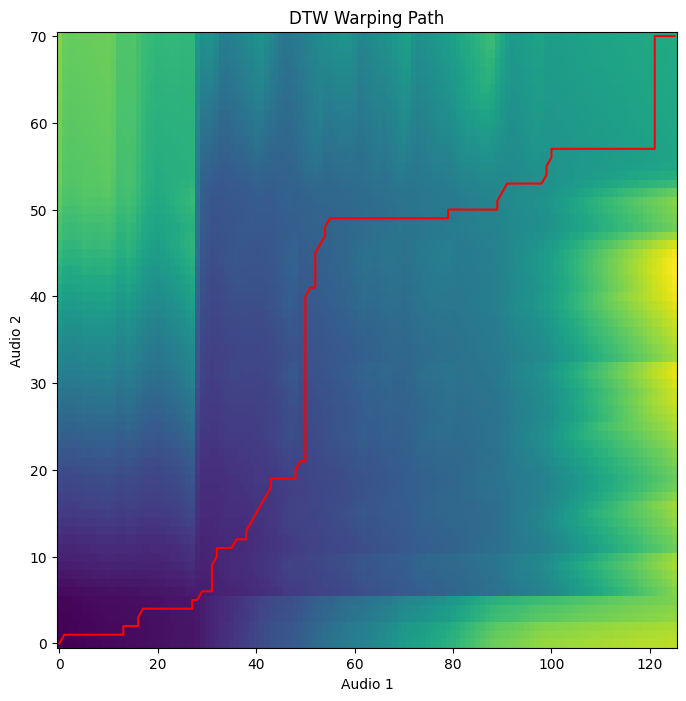

In [19]:
# ==========================================
# 18. VISUALISASI WARPING PATH 
# ==========================================
plt.figure(figsize=(8,8))

plt.imshow(
    alignment.costMatrix.T,
    origin="lower",
    cmap="viridis",
    interpolation="nearest",
    aspect="auto"
)

plt.plot(
    alignment.index1,
    alignment.index2,
    color="red"
)

plt.title("DTW Warping Path")

plt.xlabel("Audio 1")
plt.ylabel("Audio 2")

plt.show()

In [20]:
# ==========================================
# 19. FUNGSI HITUNG DTW
# ==========================================
def hitung_dtw(file1, file2):

    path1 = os.path.join(folder_path, file1)
    path2 = os.path.join(folder_path, file2)

    y1, sr1 = librosa.load(path1, sr=None)
    y2, sr2 = librosa.load(path2, sr=None)

    mfcc1 = librosa.feature.mfcc(
        y=y1,
        sr=sr1,
        n_mfcc=13
    )

    mfcc2 = librosa.feature.mfcc(
        y=y2,
        sr=sr2,
        n_mfcc=13
    )

    alignment = dtw(
        mfcc1.T,
        mfcc2.T,
        keep_internals=False
    )

    return alignment.distance

In [21]:
# ==========================================
# 20. PERCOBAAN PERHITUNGAN
# ==========================================
jarak = hitung_dtw(
    sample_df.iloc[0]["filename"],
    sample_df.iloc[5]["filename"]
)

print(jarak)

22729.569609523605


In [22]:
# ==========================================
# 21. PREDIKSI EMOSI (NEAREST NEIGHBOR)
# ==========================================
test_audio = sample_df.iloc[0]["filename"]

hasil = []

for i in range(1, len(sample_df)):

    train_audio = sample_df.iloc[i]["filename"]

    distance = hitung_dtw(
        test_audio,
        train_audio
    )

    hasil.append({
        "Audio": train_audio,
        "Emotion": sample_df.iloc[i]["emotion"],
        "DTW": distance
    })

hasil = pd.DataFrame(hasil)

hasil = hasil.sort_values(
    by="DTW"
)

hasil.head(10)

,Audio,Emotion,DTW
37,1029_IEO_HAP_HI.wav,HAP,12524.606072
7,1003_IEO_ANG_MD.wav,ANG,12843.332342
6,1046_IEO_ANG_HI.wav,ANG,14231.208862
35,1052_TSI_HAP_XX.wav,HAP,15821.234266
21,1053_IEO_HAP_MD.wav,HAP,16768.140976
34,1028_TSI_HAP_XX.wav,HAP,17436.787391
25,1004_IEO_HAP_MD.wav,HAP,17702.096296
13,1039_TSI_ANG_XX.wav,ANG,17791.952044
0,1077_IEO_ANG_HI.wav,ANG,18169.321593
16,1033_IWL_ANG_XX.wav,ANG,18175.587108


In [23]:
# ==========================================
# 22. PREDIKSI AKHIR
# ==========================================
prediksi = hasil.iloc[0]["Emotion"]

print("="*40)
print("Audio Uji")
print(test_audio)
print()
print("Prediksi Emosi :")
print(prediksi)
print("="*40)

Audio Uji
1004_IEO_ANG_HI.wav

Prediksi Emosi :
HAP


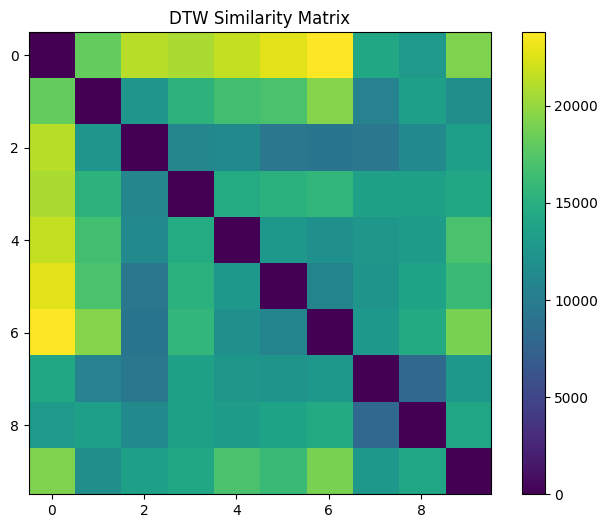

In [24]:
# ==========================================
# 23. SIMILARITY MATRIX
# ==========================================
subset = sample_df.iloc[:10]

matrix = np.zeros((10,10))

for i in range(10):
    for j in range(10):

        matrix[i,j] = hitung_dtw(
            subset.iloc[i]["filename"],
            subset.iloc[j]["filename"]
        )

plt.figure(figsize=(8,6))

plt.imshow(matrix)

plt.colorbar()

plt.title("DTW Similarity Matrix")

plt.show()

### SAVE DATA 

In [25]:
# ==========================================
# 24. MENYIMPAN DATA SAMPLING
# ==========================================
sample_df.to_csv(
    "sample_data.csv",
    index=False
)

print("Data berhasil disimpan.")

Data berhasil disimpan.


### EVALUASI MODEL 

In [26]:
# ==========================================
# 29. MENGHITUNG AKURASI : PREDIKSI SELURUH DATA
# ==========================================

prediksi = []
aktual = []

for i in range(len(sample_df)):

    test = sample_df.iloc[i]

    hasil = []

    for j in range(len(sample_df)):

        if i == j:
            continue

        train = sample_df.iloc[j]

        d = hitung_dtw(
            test["filename"],
            train["filename"]
        )

        hasil.append([
            train["emotion"],
            d
        ])

    hasil = pd.DataFrame(
        hasil,
        columns=[
            "emotion",
            "distance"
        ]
    )

    hasil = hasil.sort_values(
        by="distance"
    )

    prediksi.append(
        hasil.iloc[0]["emotion"]
    )

    aktual.append(
        test["emotion"]
    )

print("Selesai")

Selesai


In [27]:
# ==========================================
# 30. ACCURACY SCORE
# ==========================================
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

cm=confusion_matrix(
    aktual,
    prediksi
)

print(cm)

print(
    "Accuracy :",
    accuracy_score(
        aktual,
        prediksi
    )
)

[[ 1 15  4  0]
 [ 4  9  3  4]
 [ 0  4  9  7]
 [ 0  4 11  5]]
Accuracy : 0.3


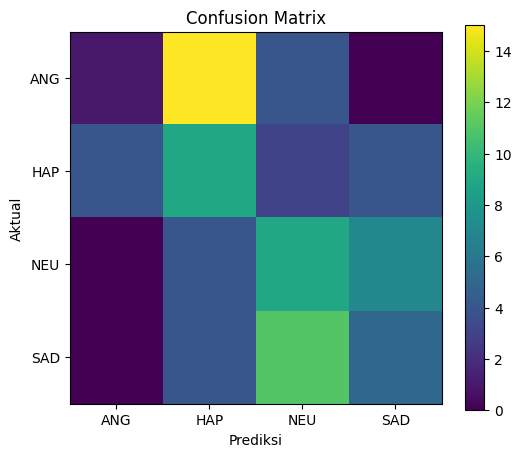

In [28]:
# ==========================================
# 31. HEATMAP CONFUSION MATRIX
# ==========================================
plt.figure(figsize=(6,5))

plt.imshow(cm)

plt.colorbar()

plt.xticks(
    range(4),
    ["ANG","HAP","NEU","SAD"]
)

plt.yticks(
    range(4),
    ["ANG","HAP","NEU","SAD"]
)

plt.xlabel("Prediksi")
plt.ylabel("Aktual")

plt.title("Confusion Matrix")

plt.show()

# SELESAI 